# Perceptron Trick - Logistic Regression 

## Code

In [1]:
from sklearn.datasets import make_classification
import pandas as pd
import numpy as np

X, y = make_classification(n_samples = 100, n_features = 2, n_informative = 1, n_redundant = 0,
                           n_classes = 2, n_clusters_per_class=1, random_state=41, hypercube = False, class_sep = 10)

Lets talk a little bit on this make classification thingy:

1) This is similar to make regression, only thing is this make classification data.
2) n_samples : Number of data points
3) n_features : Number of input columns
4) n_informative : Number of input column actually affecting the y, here it is one. This part can be a little confusing, but it will be much clearer from the plot below, see how only the x-axis affect the y, and not the y-axis, which means the second features acts as noise and a line roughly parallel to the y axis will be able to separate the data into two clusters.
5) n_redundant: Features that are linear combination of the informative ones, here the 2nd feature is just noise, so it is zero.
6) n_classes : The number of groups the y is divided into, here two (placed and unplaced) Binary data
7) n_clusters_per_class : Each class form one compact cluster.
8) random_state: seed for reproducibility
9) hypercube: Instead of sampling informative features uniformly from a hypercube, they are sampled from a Gaussian distribution (makes data more naturally clustered)
10) class_sep : Controls how separated the classes are—larger values mean groups are far apart and easier to classify.

In [2]:
import matplotlib.pyplot as plt

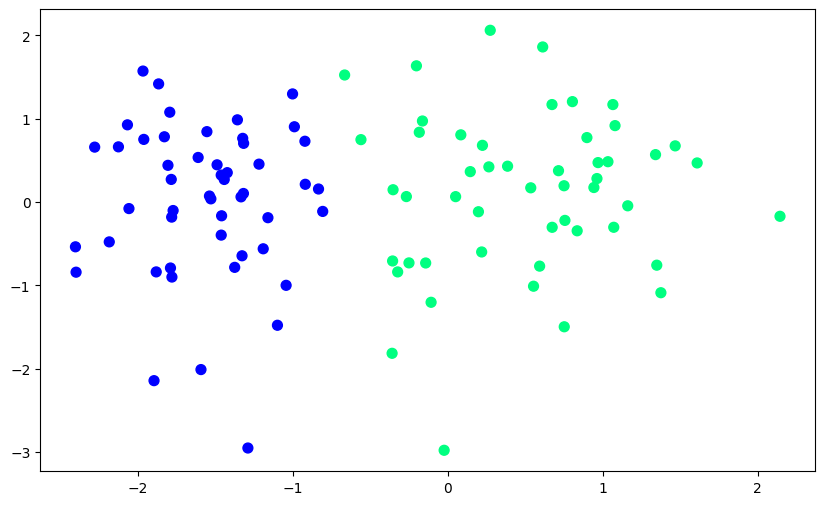

In [3]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s = 50)

In [4]:
def percpeptron(X, y):

    X = np.insert(X, 0, 1, axis = 1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):   
        j = np.random.randint(1,100)
        y_hat = step(np.dot(X[j], weights))
        weights  = weights +  lr * (y[j] - y_hat) * X[j]

    return weights[0], weights[1:]

Now the above code is the algo for the perceptron trick we discussed in the previous ipynb and is very interesting, lets break it down:

1) We are inserting a column of ones in front of the X matrix, which in our case has two features X1(informative) and X2(noise), this column acts as the identity multplicator for the intercept part in the equation of the line ( C + A * X1 + B * X2 = 0 ). It will basically act as X0 which is always 1.
2) Weights, this is the initial assumed coefficients of the equation of the line ( C + A * X1 + B * X2 = 0 ), and will be revised in 1000 epochs according to random points selected
3) lr is the learning rate, we do not need the change in each epoch to be aggresive, so we will be using a learning rate of 0.1
4) j is used for selecting a random point among the 100 in our case
5) y_hat : First we take the dot product between the X values of the randomly selected points and the weights, it is same as putting the X values in the equation of the line with coefficients same as the weights. Then step means all the values greater than equal to zero(which lie above the line - placed students) will be treated as 1 and all the values less than zero(all the points below the line - unplaced students) will be treated as 0.
6) Now we need to update the weights accordingly to the previous random point selected, now as we have mentioned, we can use a single algo for all the four poosible cases and update the weights, here is the equation for the same:
    1) ( y[j] - y_hat ) will either give 0 or 1 or -1. '0' means there is no need to update the weights for that random point, '1' means that the point should be above the line but is below and '-1' means that the point should have been below the line but is above.
    2) lr multiplier reduces the aggresiveness of the change
    3) Multiplication by X[j] make the appropriate change in direction for the weights.

In [5]:
def step(z):
    return 1 if z>0 else 0

In [6]:
intercept_, coef_ = percpeptron(X, y)

In [7]:
print(intercept_)
print(coef_)

0.9
[1.41306325 0.13556433]


Lets plot the line.

In [8]:
m = -(coef_[0]/coef_[1]) # converting Ax + By + C form to y = mx + c form
b = -(intercept_/coef_[1])

In [9]:
x_input = np.linspace(-3, 3, 100)
y_input = m*x_input + b # plotting 100 points on the line to get the line in the plot

(-3.0, 2.0)

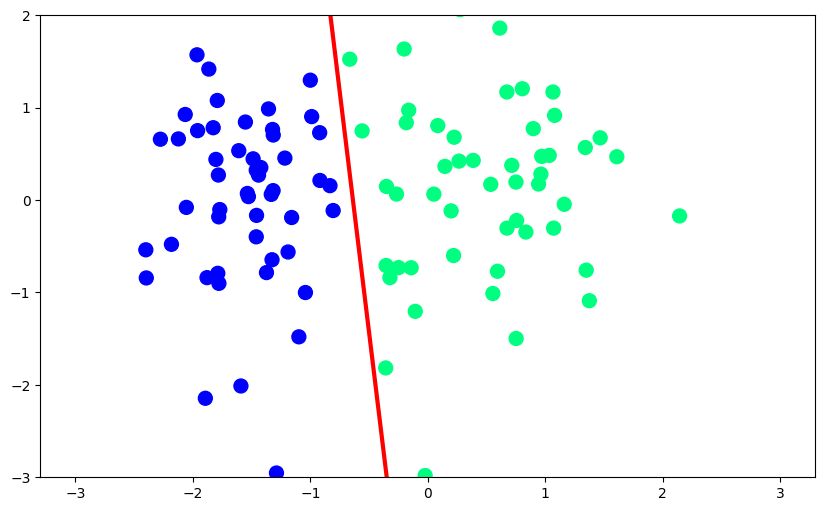

In [10]:
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color = 'red', linewidth = 3)
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
plt.ylim(-3,2)

See how beautifully our algorithm works

### Lets animate the epochs to see how our algo works here

In [11]:
def perceptron(X,y):
    
    m = []
    b = []
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(200):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))
        
    return m,b

In [12]:
m,b = perceptron(X,y)

In [13]:
%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

In [14]:
fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m[0] +b[0]
ax.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
line, = ax.plot(x_i, x_i*m[0] +b[0] , 'r-', linewidth=2)
plt.ylim(-3,3)
def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)
    # return line, ax

anim = FuncAnimation(fig, update, repeat=True, frames=200, interval=100)

<IPython.core.display.Javascript object>

## How is this different from the actual Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X, y)

LogisticRegression()

In [12]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])

In [13]:
x_input1 = np.linspace(-3, 3, 100)
y_input1 = m * x_input + b

(-3.0, 2.0)

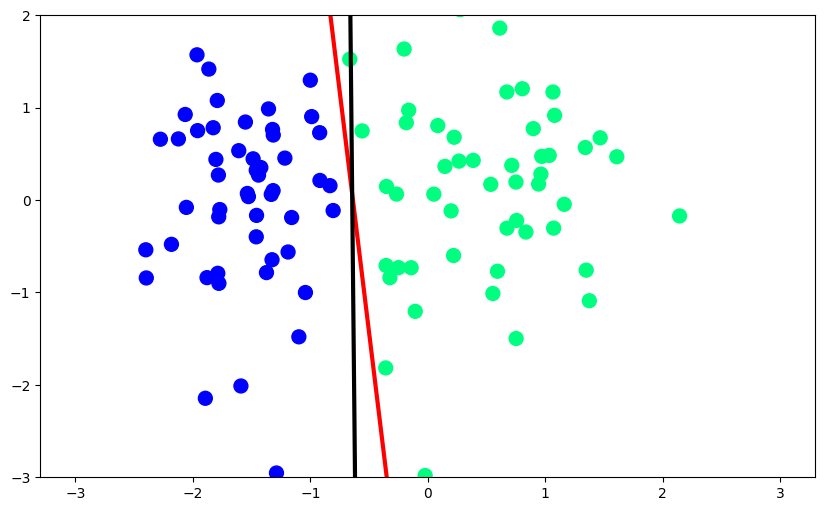

In [16]:
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color = 'red', linewidth = 3) # the one from the perceptron trick
plt.plot(x_input1, y_input1, color = 'black', linewidth = 3) # logistic regression from scikit learn
plt.scatter(X[:, 0], X[:,1], c = y, cmap = 'winter', s = 100)
plt.ylim(-3, 2)

So how are they different: Our perceptron trick stops working as soon as the line works for our data(which may work for the train data), but scikit learn line find the best fit line (which reduces the test error).